In [1]:
# import classy module
from classy import Class

In [2]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'Omega_b':0.0468,'Omega_cdm':0.2430308,'h':0.688,'A_s':2.187e-09,'n_s':0.9676,'tau_reio':0.05430842})

LambdaCDM.set({'output':'tCl,pCl,lCl,mPk','lensing':'yes','P_k_max_1/Mpc':3.0})

# run class
LambdaCDM.compute()

In [3]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from math import pi

In [4]:
import numpy as np

triangle_types = ["equi", "iso", "squeezed"]        # 3 types of triangle configs that we are interest in
h = LambdaCDM.h()                                   # get reduced Hubble for conversions to 1/Mpc

# galaxy bias:
b1, b2, bG2 = 1., 0., 0.
# b1, b2, bG2 = 2., -1., 0.1

# noise bias:
d1, d2, P_eps = 0., 0., 0.
#d1, d2, P_eps = 1., 0.1, 1e3


k_size      = 200
cos_size    = 5
mu_size     = 5
z_size      = 1

print(f"Number of iterations and class class: {k_size**2*cos_size*mu_size**2*z_size}")
print(f"Estimated memory: {k_size**2*cos_size*mu_size**2*z_size*8/(1024)**2:.3f}MB")


k = np.logspace(-3, 0, k_size)
# np.linspace(0.001, 0.05, k_size)
cos = np.linspace(-0.8, 0.9, cos_size)
mu = np.linspace(0., 0.9, mu_size)
z = np.linspace(0., 1., mu_size)



# Set the number of "clean" points
clean_points = 10  # This ensures values like 0.001, 0.01, ..., 1.0
clean_k = np.logspace(-3, 0, clean_points) # Generate the "clean" points explicitly
indices = np.linspace(0, k_size - 1, clean_points).astype(int)
k[indices] = clean_k


Number of iterations and class class: 5000000
Estimated memory: 38.147MB


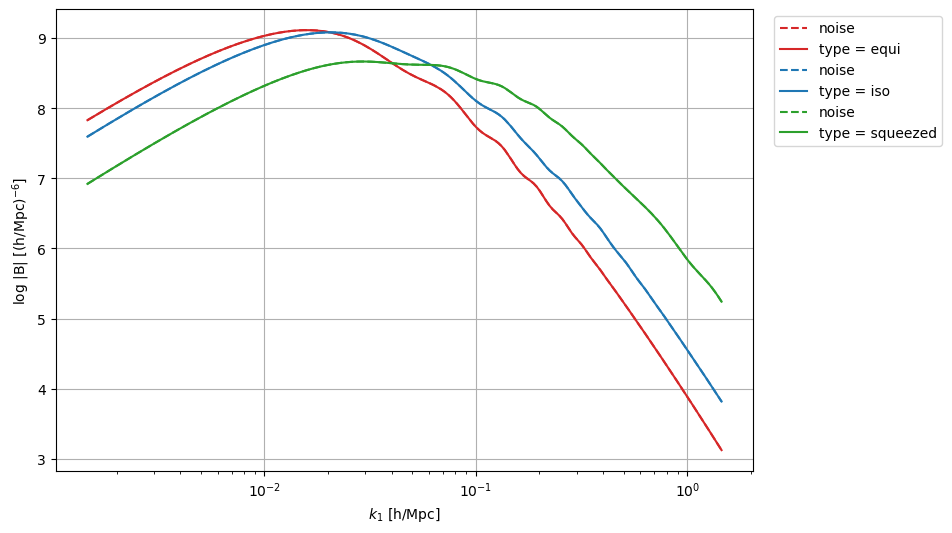

In [5]:

colors = ["tab:red", "tab:blue", "tab:green"]
plt.figure(figsize=(9, 6))
for i, type in enumerate(triangle_types):
    ln_Bk = LambdaCDM.get_bk_lin_configs(b1, b2, bG2, d1, d2, P_eps, type, k, mu, z, k_size, mu_size, z_size)
    ln_Bk2 = LambdaCDM.get_bk_lin_configs(b1, b2, bG2, 0., 0., 0., type, k, mu, z, k_size, mu_size, z_size)
    ln_Bk_1D = ln_Bk[:,0, 0, 0]
    ln_Bk_1D_2 = ln_Bk2[:,0, 0, 0]
    plt.plot(k/h, ln_Bk_1D+np.log10(h**6), color=colors[i], ls="--",label = "noise")
    plt.plot(k/h, ln_Bk_1D_2+np.log10(h**6), color=colors[i], label = f"type = {triangle_types[i]}")

plt.xscale("log")
plt.xlabel("$k_1$ [h/Mpc]")
plt.ylabel("log |B| [(h/Mpc)$^{-6}]$")
#plt.xlim(k[0], k[-1])
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))  # Moves legend outside
plt.show()




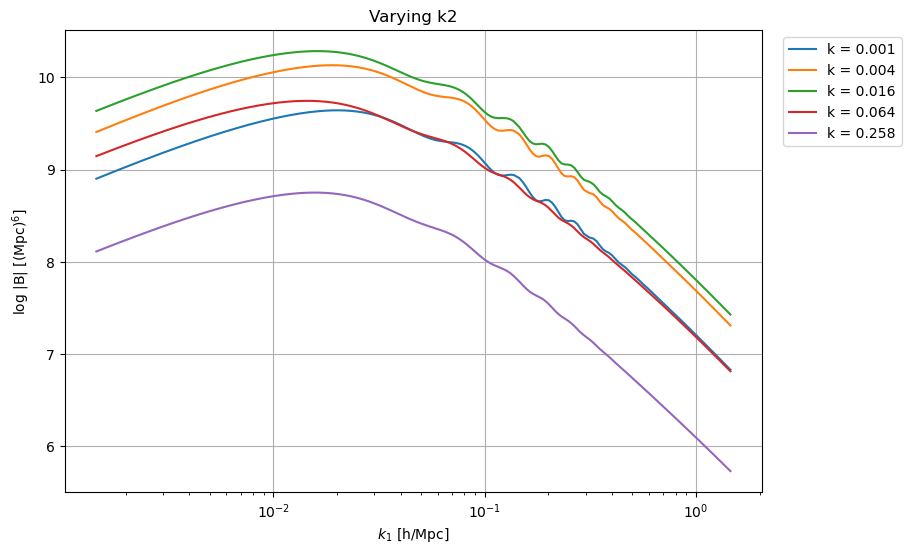

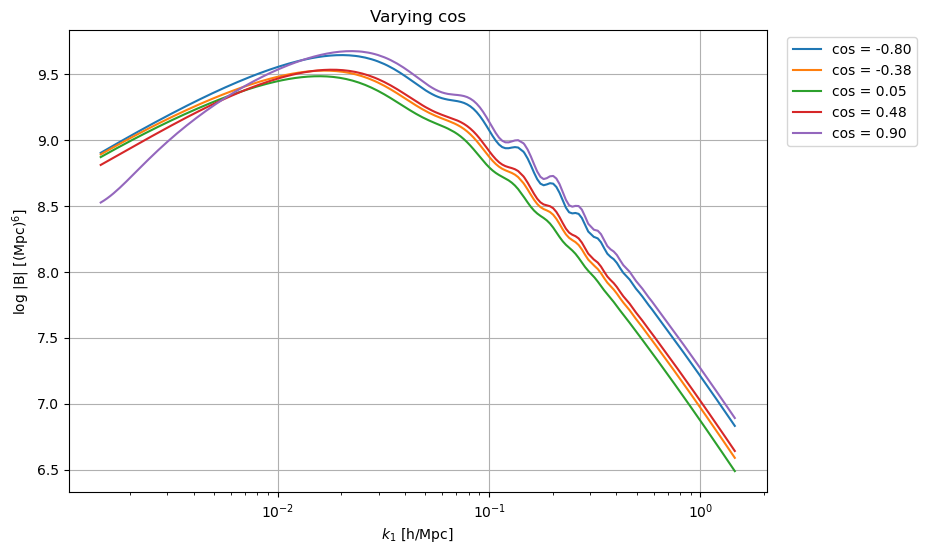

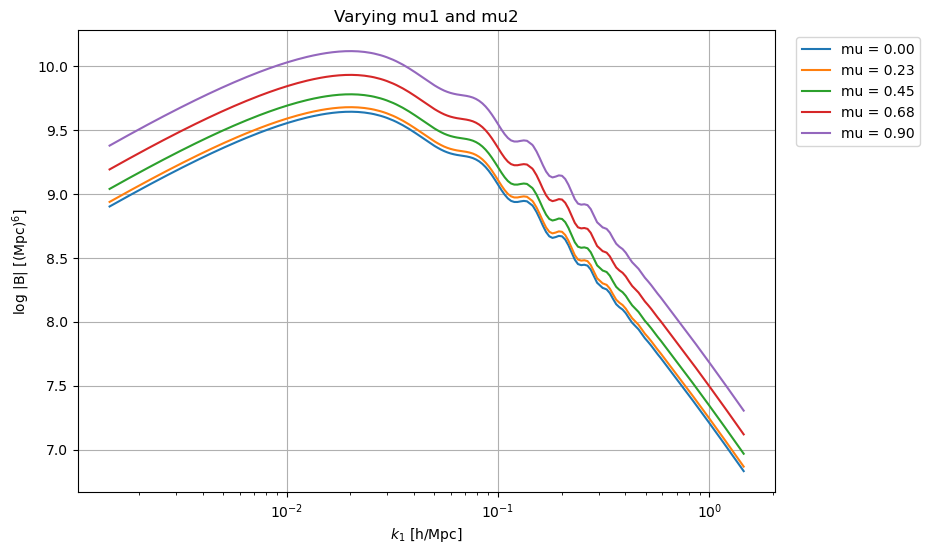

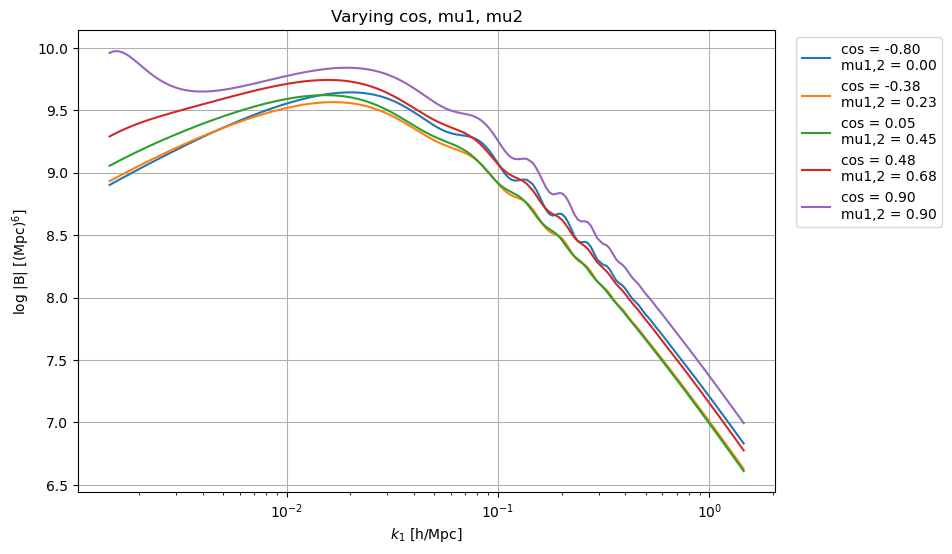

In [8]:
plt.figure(figsize=(9, 6))
ln_Bk = LambdaCDM.get_bk_lin_angle(b1, b2, bG2, d1, d2, P_eps, k, cos, mu, z, k_size, cos_size, mu_size, z_size)
for i in range(k_size):
    if i%(k_size//5) == 0:
        ln_Bk_1D = ln_Bk[:,i, 0, 0, 0, 0]
        plt.plot(k/h, ln_Bk_1D, label = f"k = {k[i]:.3f}")
plt.title("Varying k2")
plt.xscale("log")
plt.xlabel("$k_1$ [h/Mpc]")
plt.ylabel("log |B| [(Mpc)$^{6}]$")
#plt.xlim(k[0], k[-1])
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))  # Moves legend outside
plt.show()

plt.figure(figsize=(9, 6))
for i in range(cos_size):
    ln_Bk_1D = ln_Bk[:,0, i, 0, 0, 0]
    plt.plot(k/h, ln_Bk_1D, label = f"cos = {cos[i]:.2f}")
plt.title("Varying cos")
plt.xscale("log")
plt.xlabel("$k_1$ [h/Mpc]")
plt.ylabel("log |B| [(Mpc)$^{6}]$")
#plt.xlim(k[0], k[-1])
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))  # Moves legend outside
plt.show()

plt.figure(figsize=(9, 6))
for i in range(mu_size):
    ln_Bk_1D = ln_Bk[:,0, 0, i, i, 0]
    plt.plot(k/h, ln_Bk_1D, label = f"mu = {mu[i]:.2f}")
plt.title("Varying mu1 and mu2")
plt.xscale("log")
plt.xlabel("$k_1$ [h/Mpc]")
plt.ylabel("log |B| [(Mpc)$^{6}]$")
#plt.xlim(k[0], k[-1])
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))  # Moves legend outside
plt.show()

if mu_size == cos_size:
    plt.figure(figsize=(9, 6))
    for i in range(cos_size):
        ln_Bk_1D = ln_Bk[:,0, i, i, i, 0]
        plt.plot(k/h, ln_Bk_1D, label = f"cos = {cos[i]:.2f}\nmu1,2 = {mu[i]:.2f}")
    plt.title("Varying cos, mu1, mu2")
    plt.xscale("log")
    plt.xlabel("$k_1$ [h/Mpc]")
    plt.ylabel("log |B| [(Mpc)$^{6}]$")
    #plt.xlim(k[0], k[-1])
    plt.grid()
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))  # Moves legend outside
    plt.show()


In [7]:
# optional: reset parameters to default in case you want 
# to set different parameters and rerun LambdaCDM.compute()
LambdaCDM.empty()